In [1]:
from pathlib import Path
import os, random, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_pre
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
DATA = Path("dataset")
OUT = Path("outputs")
OUT.mkdir(exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Dataset path:", DATA.resolve())

TensorFlow: 2.21.0
Dataset path: C:\Users\devds\Documents\30 Session Ass\dataset


## 1. Dataset audit

In [2]:
def audit_dataset(root):
    rows = []
    for task in ["headphones", "tshirts", "glasses"]:
        task_dir = root / task
        for split in ["train", "val"]:
            split_dir = task_dir / split
            if not split_dir.exists():
                continue
            for class_dir in sorted(split_dir.iterdir()):
                if class_dir.is_dir():
                    files = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.jpeg")) + list(class_dir.glob("*.png"))
                    rows.append({
                        "dataset": task,
                        "split": split,
                        "class": class_dir.name,
                        "images": len(files)
                    })
    return pd.DataFrame(rows)

audit = audit_dataset(DATA)
display(audit)
print("\nTotal images:", audit["images"].sum())

,dataset,split,class,images
0,headphones,train,earbuds,30
1,headphones,train,neckband,30
2,headphones,train,over_ear,30
3,headphones,val,earbuds,10
4,headphones,val,neckband,10
5,headphones,val,over_ear,10
6,tshirts,train,plain,30
7,tshirts,train,printed,30
8,tshirts,train,striped,30
9,tshirts,val,plain,10



Total images: 310


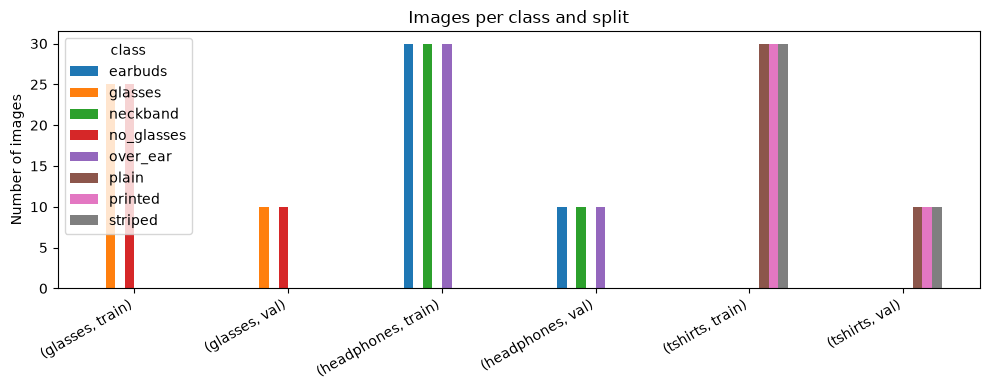

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
pivot = audit.pivot_table(index=["dataset", "split"], columns="class", values="images", fill_value=0)
pivot.plot(kind="bar", ax=ax)
ax.set_title("Images per class and split")
ax.set_ylabel("Number of images")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 2. Visual inspection of the supplied images

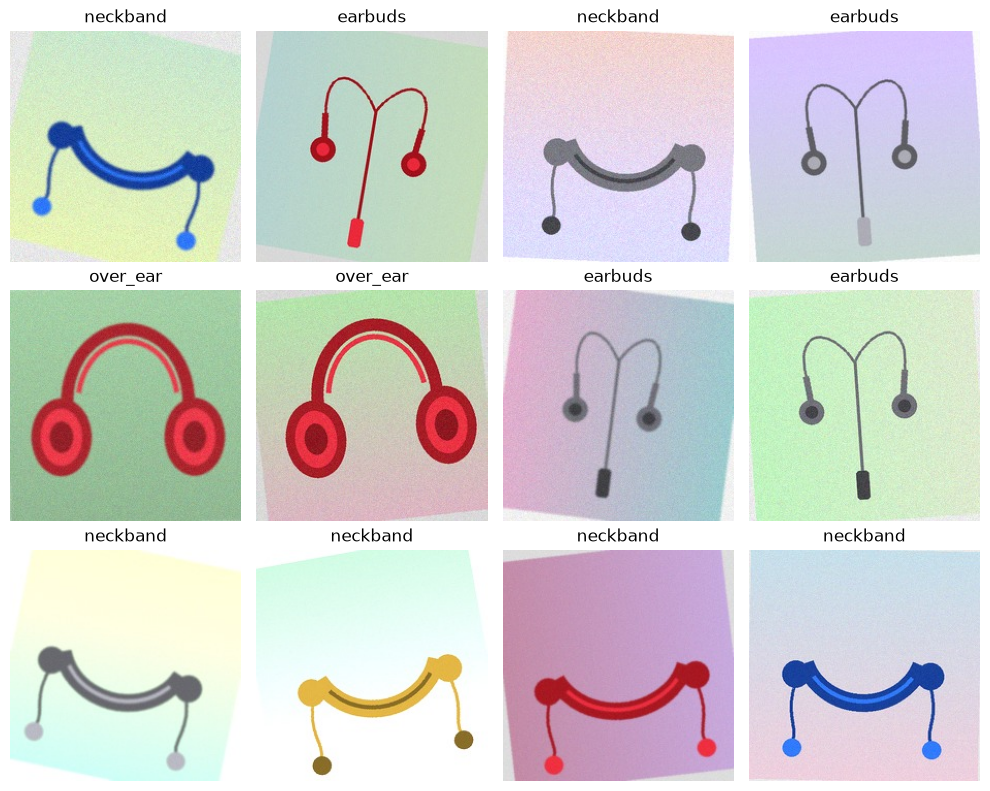

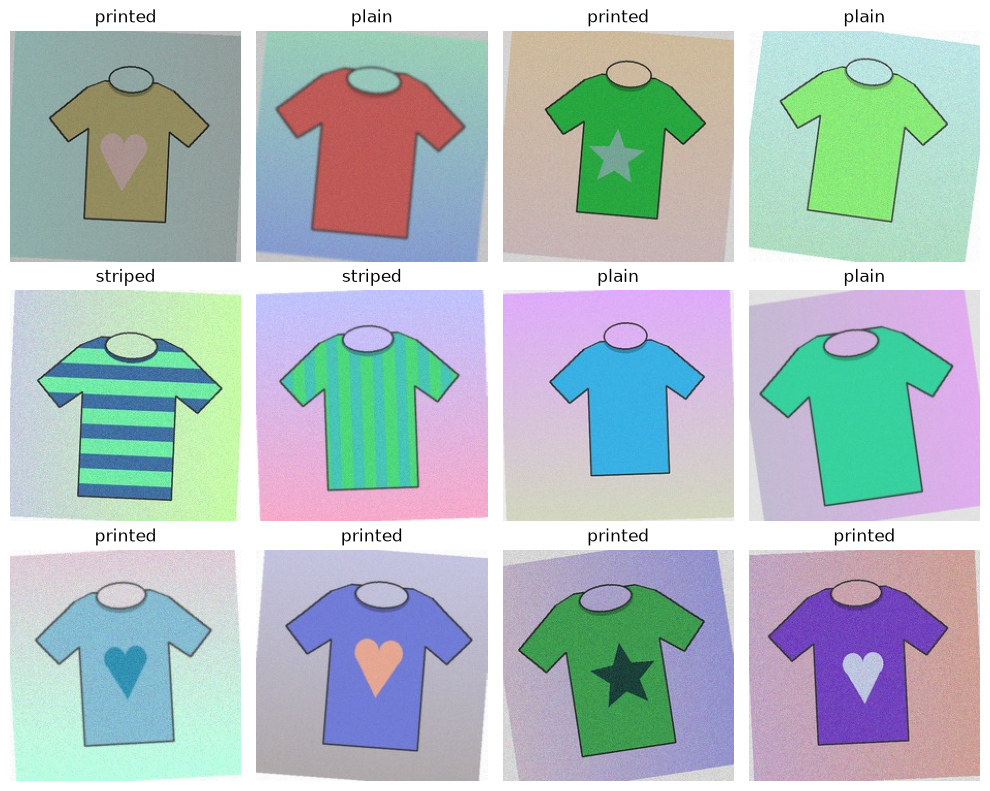

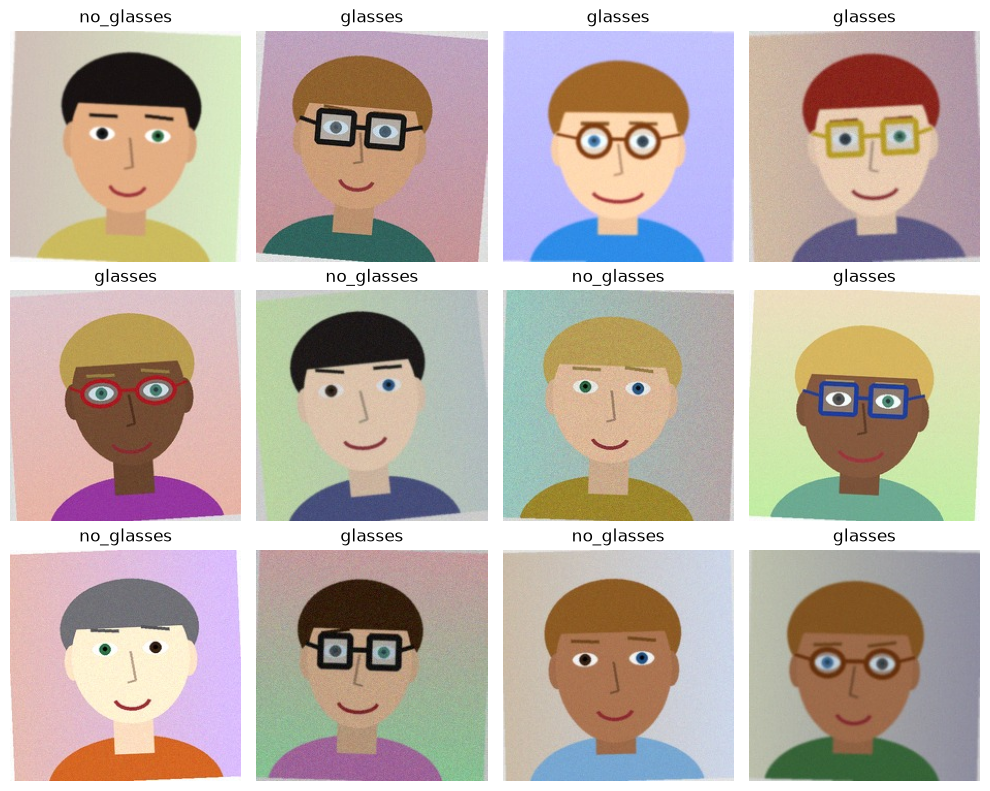

In [4]:
def show_random_images(dataset_name, split="train", n=12):
    root = DATA / dataset_name / split
    files = []
    for class_dir in sorted(root.iterdir()):
        if class_dir.is_dir():
            files.extend([(p, class_dir.name) for p in class_dir.glob("*.jpg")])
    random.Random(SEED).shuffle(files)
    files = files[:n]

    fig, axes = plt.subplots(3, 4, figsize=(10, 8))
    for ax, (path, label) in zip(axes.ravel(), files):
        ax.imshow(load_img(path))
        ax.set_title(label)
        ax.axis("off")
    for ax in axes.ravel()[len(files):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_random_images("headphones")
show_random_images("tshirts")
show_random_images("glasses")

## 3. Task 1 – Data augmentation

The original assignment asks for augmentation on 20 food images. Since the supplied ZIP contains no food folder, the same experiment is demonstrated on **20 supplied headphone images**.

Augmentations:
- rotation
- horizontal flip
- zoom
- width/height shift
- brightness variation

Found 90 images belonging to 3 classes.
20 original images: (20, 224, 224, 3)


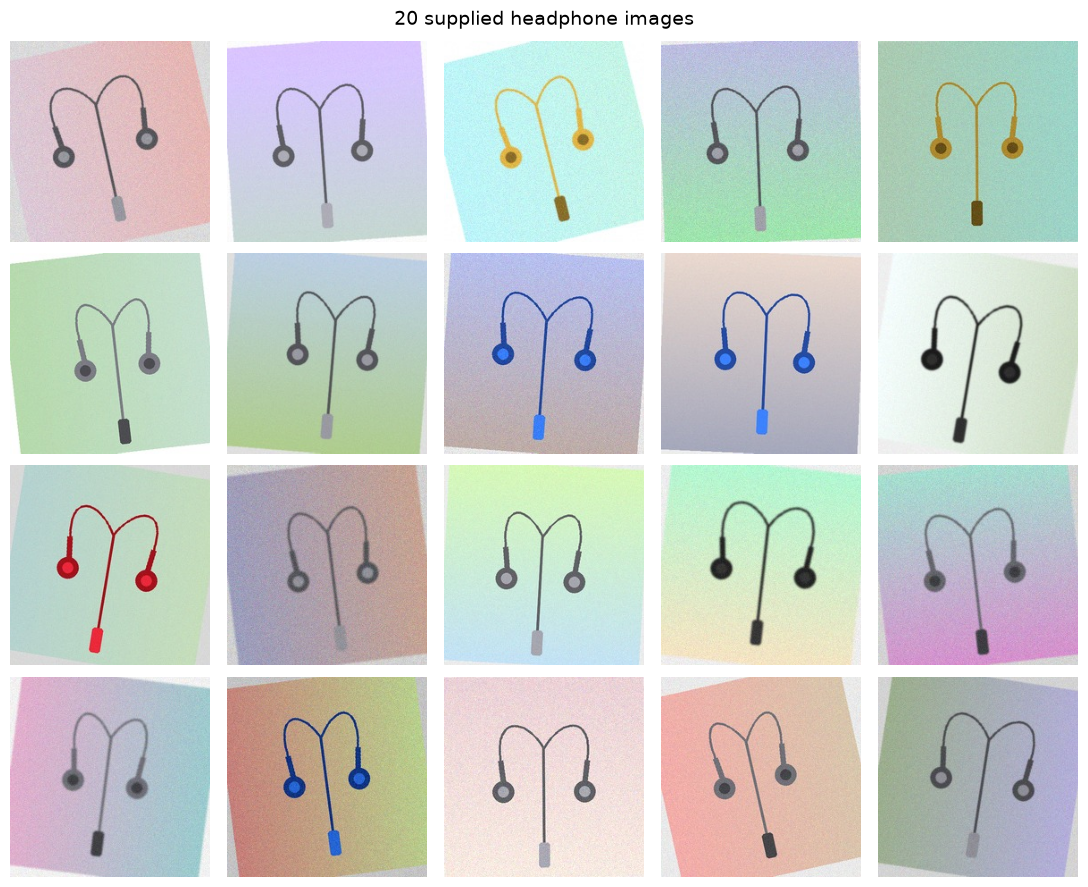

In [5]:
headphone_train = DATA / "headphones" / "train"

augmenter = ImageDataGenerator(
    rotation_range=35,
    horizontal_flip=True,
    zoom_range=0.25,
    width_shift_range=0.12,
    height_shift_range=0.12,
    brightness_range=(0.75, 1.25),
    fill_mode="nearest"
)

plain_flow = ImageDataGenerator().flow_from_directory(
    headphone_train,
    target_size=IMG_SIZE,
    batch_size=20,
    class_mode=None,
    shuffle=False
)

originals = next(plain_flow)
print("20 original images:", originals.shape)

fig, axes = plt.subplots(4, 5, figsize=(11, 9))
for ax, im in zip(axes.ravel(), originals):
    ax.imshow(im.astype("uint8"))
    ax.axis("off")
plt.suptitle("20 supplied headphone images", fontsize=14)
plt.tight_layout()
plt.show()

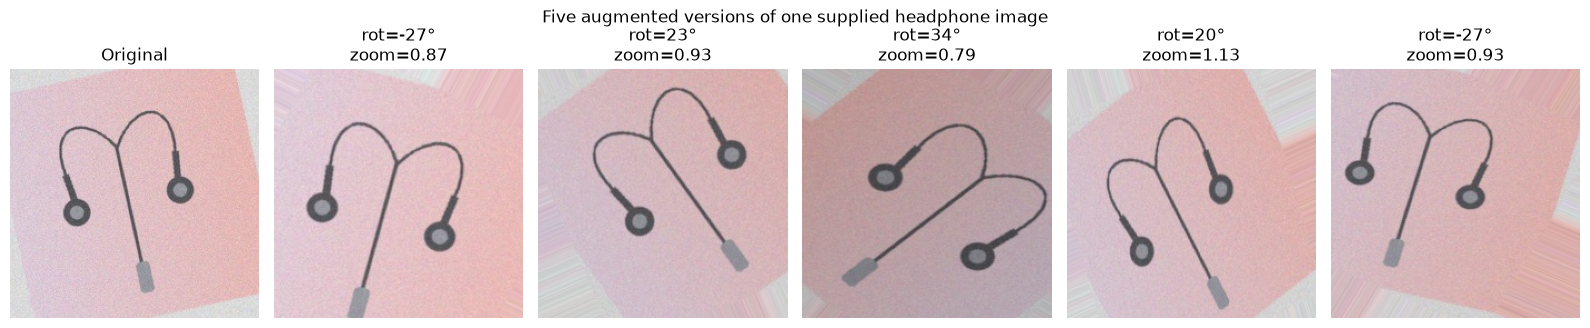

In [6]:
# Display five augmented versions of one real supplied image
x = originals[0]

fig, axes = plt.subplots(1, 6, figsize=(16, 3.5))
axes[0].imshow(x.astype("uint8"))
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(5):
    params = augmenter.get_random_transform(x.shape, seed=SEED + i + 1)
    aug = augmenter.apply_transform(x, params)
    axes[i + 1].imshow(np.clip(aug, 0, 255).astype("uint8"))
    axes[i + 1].set_title(
        f"rot={params['theta']:.0f}°\nzoom={params['zx']:.2f}"
    )
    axes[i + 1].axis("off")

plt.suptitle("Five augmented versions of one supplied headphone image")
plt.tight_layout()
plt.savefig(OUT / "task1_augmentations.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Task 2 – VGG16 feature extraction

The original task requests 30 sneaker images. No sneaker folder is present in the supplied ZIP, so this notebook extracts VGG16 features from **30 supplied headphone images**.

`include_top=False` removes the ImageNet classifier and leaves the convolutional feature extractor.

In [7]:
# Select exactly 30 headphone images
headphone_files = sorted(headphone_train.glob("*/*.jpg"))
assert len(headphone_files) >= 30, "At least 30 headphone images are required."

files30 = headphone_files[:30]
X = np.stack([
    img_to_array(load_img(path, target_size=IMG_SIZE))
    for path in files30
])

print("Input shape:", X.shape)

vgg = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

features = vgg.predict(vgg_pre(X.copy()), batch_size=10, verbose=1)
print("VGG16 feature shape:", features.shape)

np.save(OUT / "headphone_features_vgg16.npy", features)
pooled = features.mean(axis=(1, 2))
np.save(OUT / "headphone_features_vgg16_pooled.npy", pooled)

print("Saved:")
print(OUT / "headphone_features_vgg16.npy")
print(OUT / "headphone_features_vgg16_pooled.npy")

Input shape: (30, 224, 224, 3)
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step
VGG16 feature shape: (30, 7, 7, 512)
Saved:
outputs\headphone_features_vgg16.npy
outputs\headphone_features_vgg16_pooled.npy


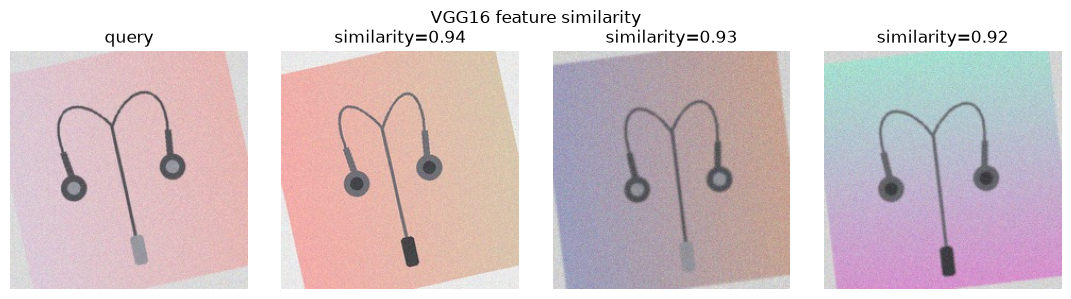

In [8]:
# Nearest-neighbour sanity check using the extracted 512-D pooled features
unit = pooled / np.maximum(np.linalg.norm(pooled, axis=1, keepdims=True), 1e-8)
similarity = unit @ unit[0]
nearest = np.argsort(-similarity)[:4]

fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for ax, idx in zip(axes, nearest):
    ax.imshow(X[idx].astype("uint8"))
    ax.set_title("query" if idx == 0 else f"similarity={similarity[idx]:.2f}")
    ax.axis("off")
plt.suptitle("VGG16 feature similarity")
plt.tight_layout()
plt.show()

## 5. Task 3 – ResNet50 fine-tuning: glasses vs no-glasses

Requirement: **only the last 20 ResNet50 layers are trainable** during fine-tuning.

The model is trained in two phases:
1. Frozen ResNet50 + new classifier head.
2. Unfreeze only the last 20 ResNet50 layers and continue with a smaller learning rate.

In [9]:
glass_dir = DATA / "glasses"

train_aug = ImageDataGenerator(
    preprocessing_function=resnet_pre,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2)
)
val_aug = ImageDataGenerator(preprocessing_function=resnet_pre)

glass_train = train_aug.flow_from_directory(
    glass_dir / "train",
    target_size=IMG_SIZE,
    batch_size=8,
    class_mode="binary",
    seed=SEED
)
glass_val = val_aug.flow_from_directory(
    glass_dir / "val",
    target_size=IMG_SIZE,
    batch_size=8,
    class_mode="binary",
    shuffle=False
)

print("Class mapping:", glass_train.class_indices)

Found 50 images belonging to 2 classes.
Found 20 images belonging to 2 classes.
Class mapping: {'glasses': 0, 'no_glasses': 1}


In [10]:
base = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base.trainable = False

inp = keras.Input(shape=(224, 224, 3))
x = base(inp, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
out = layers.Dense(1, activation="sigmoid")(x)
glass_model = keras.Model(inp, out)

glass_model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

warm_history = glass_model.fit(
    glass_train,
    validation_data=glass_val,
    epochs=5,
    verbose=2
)

Epoch 1/5
7/7 - 28s - 4s/step - accuracy: 0.6400 - loss: 0.8071 - val_accuracy: 0.6500 - val_loss: 0.5639
Epoch 2/5
7/7 - 7s - 937ms/step - accuracy: 0.6600 - loss: 0.6129 - val_accuracy: 0.8000 - val_loss: 0.4445
Epoch 3/5
7/7 - 7s - 939ms/step - accuracy: 0.8400 - loss: 0.4312 - val_accuracy: 0.9000 - val_loss: 0.3514
Epoch 4/5
7/7 - 7s - 970ms/step - accuracy: 0.8600 - loss: 0.3236 - val_accuracy: 0.9500 - val_loss: 0.2798
Epoch 5/5
7/7 - 10s - 1s/step - accuracy: 0.9400 - loss: 0.2105 - val_accuracy: 0.9000 - val_loss: 0.2513


In [11]:
# Fine-tune exactly the last 20 ResNet50 layers
N_UNFREEZE = 20
base.trainable = True

for layer in base.layers[:-N_UNFREEZE]:
    layer.trainable = False

trainable_base = [layer.name for layer in base.layers if layer.trainable]
print("Trainable ResNet50 layers:", len(trainable_base))
print(trainable_base)

assert len(trainable_base) == N_UNFREEZE

glass_model.compile(
    optimizer=optimizers.Adam(learning_rate=5e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

fine_history = glass_model.fit(
    glass_train,
    validation_data=glass_val,
    epochs=10,
    verbose=2
)

Trainable ResNet50 layers: 20
['conv5_block2_1_conv', 'conv5_block2_1_bn', 'conv5_block2_1_relu', 'conv5_block2_2_conv', 'conv5_block2_2_bn', 'conv5_block2_2_relu', 'conv5_block2_3_conv', 'conv5_block2_3_bn', 'conv5_block2_add', 'conv5_block2_out', 'conv5_block3_1_conv', 'conv5_block3_1_bn', 'conv5_block3_1_relu', 'conv5_block3_2_conv', 'conv5_block3_2_bn', 'conv5_block3_2_relu', 'conv5_block3_3_conv', 'conv5_block3_3_bn', 'conv5_block3_add', 'conv5_block3_out']
Epoch 1/10
7/7 - 37s - 5s/step - accuracy: 0.8400 - loss: 0.2695 - val_accuracy: 0.9500 - val_loss: 0.1464
Epoch 2/10
7/7 - 8s - 1s/step - accuracy: 0.9800 - loss: 0.0827 - val_accuracy: 0.9000 - val_loss: 0.1822
Epoch 3/10
7/7 - 8s - 1s/step - accuracy: 1.0000 - loss: 0.0390 - val_accuracy: 0.9000 - val_loss: 0.2150
Epoch 4/10
7/7 - 8s - 1s/step - accuracy: 1.0000 - loss: 0.0441 - val_accuracy: 0.9000 - val_loss: 0.2264
Epoch 5/10
7/7 - 11s - 2s/step - accuracy: 0.9800 - loss: 0.0332 - val_accuracy: 0.9000 - val_loss: 0.1783
E

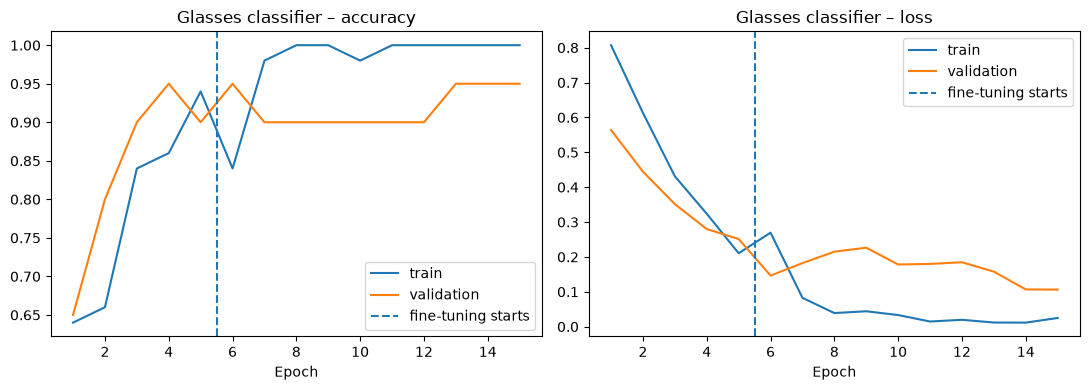

Final validation accuracy: 0.950


In [12]:
def combine_histories(*histories):
    result = {}
    for h in histories:
        for k, values in h.history.items():
            result.setdefault(k, []).extend(values)
    return result

hist3 = combine_histories(warm_history, fine_history)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
epochs = range(1, len(hist3["loss"]) + 1)

axes[0].plot(epochs, hist3["accuracy"], label="train")
axes[0].plot(epochs, hist3["val_accuracy"], label="validation")
axes[0].axvline(5.5, linestyle="--", label="fine-tuning starts")
axes[0].set_title("Glasses classifier – accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, hist3["loss"], label="train")
axes[1].plot(epochs, hist3["val_loss"], label="validation")
axes[1].axvline(5.5, linestyle="--", label="fine-tuning starts")
axes[1].set_title("Glasses classifier – loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

loss, acc = glass_model.evaluate(glass_val, verbose=0)
print(f"Final validation accuracy: {acc:.3f}")

              precision    recall  f1-score   support

     glasses       1.00      0.90      0.95        10
  no_glasses       0.91      1.00      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20



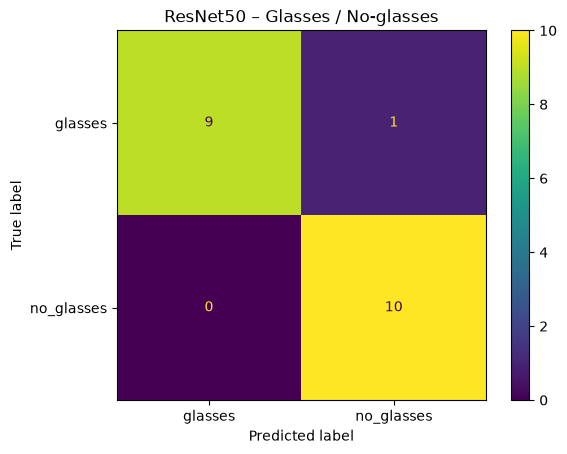

In [13]:
pred_prob = glass_model.predict(glass_val, verbose=0).ravel()
pred = (pred_prob >= 0.5).astype(int)
true = glass_val.classes
labels = list(glass_val.class_indices.keys())

print(classification_report(true, pred, target_names=labels))

cm = confusion_matrix(true, pred)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(values_format="d")
plt.title("ResNet50 – Glasses / No-glasses")
plt.show()

## 6. Task 4 – Feature extraction vs fine-tuning on T-shirts

Both approaches use the same ResNet50 architecture and the same T-shirt dataset.

- **Model A:** ResNet50 remains completely frozen.
- **Model B:** first trains the classifier head, then unfreezes the last 30 layers.

This is a fair comparison of how much task-specific fine-tuning helps.

In [14]:
shirt_dir = DATA / "tshirts"

def make_shirt_flows(batch=16):
    train_gen = ImageDataGenerator(
        preprocessing_function=resnet_pre,
        rotation_range=15,
        zoom_range=0.15,
        width_shift_range=0.10,
        height_shift_range=0.10,
        horizontal_flip=True
    )
    val_gen = ImageDataGenerator(preprocessing_function=resnet_pre)

    tr = train_gen.flow_from_directory(
        shirt_dir / "train",
        target_size=IMG_SIZE,
        batch_size=batch,
        class_mode="categorical",
        seed=SEED
    )
    va = val_gen.flow_from_directory(
        shirt_dir / "val",
        target_size=IMG_SIZE,
        batch_size=batch,
        class_mode="categorical",
        shuffle=False
    )
    return tr, va

def build_resnet_classifier(n_classes):
    b = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    b.trainable = False
    inp = keras.Input((224, 224, 3))
    x = b(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    out = layers.Dense(n_classes, activation="softmax")(x)
    model = keras.Model(inp, out)
    return model, b

In [15]:
# Model A: pure feature extraction
tf.keras.utils.set_random_seed(SEED)
trA, vaA = make_shirt_flows()
model_A, base_A = build_resnet_classifier(trA.num_classes)

model_A.compile(
    optimizer=optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

hist_A = model_A.fit(
    trA, validation_data=vaA, epochs=12, verbose=2
)

Found 90 images belonging to 3 classes.
Found 30 images belonging to 3 classes.
Epoch 1/12
6/6 - 33s - 5s/step - accuracy: 0.2778 - loss: 1.5625 - val_accuracy: 0.5000 - val_loss: 1.0681
Epoch 2/12
6/6 - 14s - 2s/step - accuracy: 0.3222 - loss: 1.2961 - val_accuracy: 0.5333 - val_loss: 0.8897
Epoch 3/12
6/6 - 11s - 2s/step - accuracy: 0.4889 - loss: 1.0030 - val_accuracy: 0.6333 - val_loss: 0.7485
Epoch 4/12
6/6 - 12s - 2s/step - accuracy: 0.5444 - loss: 0.8849 - val_accuracy: 0.7000 - val_loss: 0.6706
Epoch 5/12
6/6 - 11s - 2s/step - accuracy: 0.7000 - loss: 0.7049 - val_accuracy: 0.8333 - val_loss: 0.5915
Epoch 6/12
6/6 - 11s - 2s/step - accuracy: 0.7333 - loss: 0.5669 - val_accuracy: 0.7333 - val_loss: 0.5109
Epoch 7/12
6/6 - 11s - 2s/step - accuracy: 0.7333 - loss: 0.5773 - val_accuracy: 0.8333 - val_loss: 0.4656
Epoch 8/12
6/6 - 12s - 2s/step - accuracy: 0.8333 - loss: 0.4755 - val_accuracy: 0.8667 - val_loss: 0.4515
Epoch 9/12
6/6 - 11s - 2s/step - accuracy: 0.7889 - loss: 0.4492

In [16]:
# Model B: warm-up, then fine-tune the last 30 layers
tf.keras.utils.set_random_seed(SEED)
trB, vaB = make_shirt_flows()
model_B, base_B = build_resnet_classifier(trB.num_classes)

model_B.compile(
    optimizer=optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

warm_B = model_B.fit(
    trB, validation_data=vaB, epochs=4, verbose=2
)

N_UNFREEZE_SHIRT = 30
base_B.trainable = True
for layer in base_B.layers[:-N_UNFREEZE_SHIRT]:
    layer.trainable = False

assert sum(layer.trainable for layer in base_B.layers) == N_UNFREEZE_SHIRT

model_B.compile(
    optimizer=optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_B = model_B.fit(
    trB, validation_data=vaB, epochs=8, verbose=2
)

hist_B = combine_histories(warm_B, fine_B)

Found 90 images belonging to 3 classes.
Found 30 images belonging to 3 classes.
Epoch 1/4
6/6 - 32s - 5s/step - accuracy: 0.2778 - loss: 1.5625 - val_accuracy: 0.5000 - val_loss: 1.0681
Epoch 2/4
6/6 - 15s - 2s/step - accuracy: 0.3222 - loss: 1.2961 - val_accuracy: 0.5333 - val_loss: 0.8897
Epoch 3/4
6/6 - 11s - 2s/step - accuracy: 0.4889 - loss: 1.0030 - val_accuracy: 0.6333 - val_loss: 0.7485
Epoch 4/4
6/6 - 11s - 2s/step - accuracy: 0.5444 - loss: 0.8849 - val_accuracy: 0.7000 - val_loss: 0.6706
Epoch 1/8
6/6 - 46s - 8s/step - accuracy: 0.7333 - loss: 0.7097 - val_accuracy: 0.7000 - val_loss: 0.6274
Epoch 2/8
6/6 - 14s - 2s/step - accuracy: 0.9222 - loss: 0.2029 - val_accuracy: 0.6000 - val_loss: 1.2169
Epoch 3/8
6/6 - 14s - 2s/step - accuracy: 0.9778 - loss: 0.0987 - val_accuracy: 0.5333 - val_loss: 1.7468
Epoch 4/8
6/6 - 14s - 2s/step - accuracy: 0.9778 - loss: 0.0759 - val_accuracy: 0.6000 - val_loss: 1.8050
Epoch 5/8
6/6 - 14s - 2s/step - accuracy: 0.9889 - loss: 0.0454 - val_ac

,Approach,Best validation accuracy,Final validation accuracy
0,Feature extraction,0.900000,0.866667
1,Fine-tuning,0.933333,0.933333


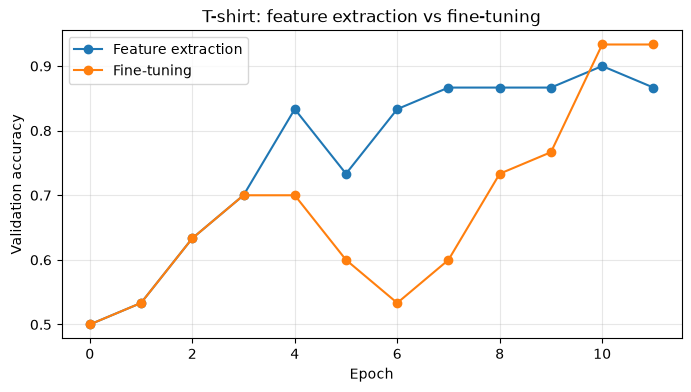

In [17]:
result = pd.DataFrame({
    "Approach": ["Feature extraction", "Fine-tuning"],
    "Best validation accuracy": [
        max(hist_A.history["val_accuracy"]),
        max(hist_B["val_accuracy"])
    ],
    "Final validation accuracy": [
        hist_A.history["val_accuracy"][-1],
        hist_B["val_accuracy"][-1]
    ]
})
display(result)

plt.figure(figsize=(8, 4))
plt.plot(hist_A.history["val_accuracy"], marker="o", label="Feature extraction")
plt.plot(hist_B["val_accuracy"], marker="o", label="Fine-tuning")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("T-shirt: feature extraction vs fine-tuning")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Task 5 – MobileNetV2 headphone classifier

Three classes are available:
- earbuds
- neckband
- over_ear

MobileNetV2 is smaller and faster than ResNet50, making it a useful model for a lightweight image-classification application.

In [18]:
hp_train = ImageDataGenerator(
    preprocessing_function=mobilenet_pre,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True
)
hp_val = ImageDataGenerator(preprocessing_function=mobilenet_pre)

hp_tr = hp_train.flow_from_directory(
    headphone_train,
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode="categorical",
    seed=SEED
)
hp_va = hp_val.flow_from_directory(
    DATA / "headphones" / "val",
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)

mobile_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
mobile_base.trainable = False

inp = keras.Input((224, 224, 3))
x = mobile_base(inp, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
out = layers.Dense(hp_tr.num_classes, activation="softmax")(x)
mobile_model = keras.Model(inp, out)

mobile_model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mobile_history = mobile_model.fit(
    hp_tr, validation_data=hp_va, epochs=10, verbose=2
)

Found 90 images belonging to 3 classes.
Found 30 images belonging to 3 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/10
6/6 - 21s - 4s/step - accuracy: 0.5778 - loss: 0.8552 - val_accuracy: 1.0000 - val_loss: 0.2460
Epoch 2/10
6/6 - 4s - 708ms/step - accuracy: 0.9000 - loss: 0.3101 - val_accuracy: 1.0000 - val_loss: 0.0772
Epoch 3/10
6/6 - 5s - 784ms/step - accuracy: 1.0000 - loss: 0.0994 - val_accuracy: 1.0000 - val_loss: 0.0281
Epoch 4/10
6/6 - 5s - 780ms/step - accuracy: 0.9889 - loss: 0.0614 - val_accuracy: 1.0000 - val_loss: 0.0135
Epoch 5/10
6/6 - 5s - 759ms/step - accuracy: 1.0000 - loss: 0.0222 - val_accuracy: 1.0000 - val_loss: 0.0083
Epoch 6/10
6/6 - 5s - 762ms/step - accuracy: 0.9889 - loss: 0.0344 - val_accuracy: 1.0000 - val_loss: 0.0062
Epoch 7/10
6/6 - 5s - 759ms/step - accuracy: 1.0000 - loss: 0.0168 - val_accuracy: 1.0000 - val_loss: 0.0049
Epoch 8/10
6/6 - 4s - 680ms/step - accuracy: 1.0000 - loss: 0.0114 - val_accuracy: 1.0000 - val_loss: 0.0041
E

              precision    recall  f1-score   support

     earbuds       1.00      1.00      1.00        10
    neckband       1.00      1.00      1.00        10
    over_ear       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



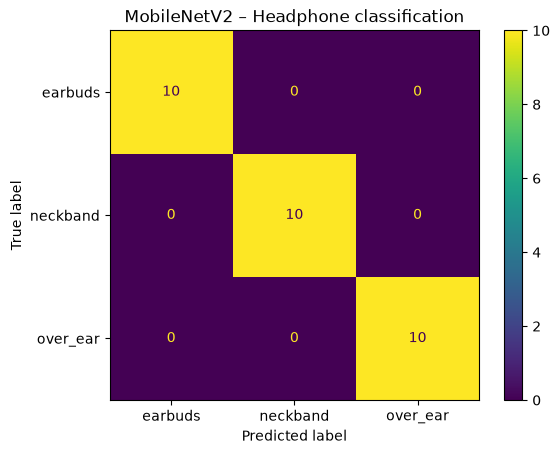

In [19]:
hp_prob = mobile_model.predict(hp_va, verbose=0)
hp_pred = np.argmax(hp_prob, axis=1)
hp_true = hp_va.classes
hp_labels = list(hp_va.class_indices.keys())

print(classification_report(hp_true, hp_pred, target_names=hp_labels))

cm = confusion_matrix(hp_true, hp_pred)
ConfusionMatrixDisplay(cm, display_labels=hp_labels).plot(values_format="d")
plt.title("MobileNetV2 – Headphone classification")
plt.show()

In [20]:
# Save a compact summary of the supplied dataset
summary = audit.groupby(["dataset", "split"])["images"].sum().reset_index()
summary.to_csv(OUT / "dataset_summary.csv", index=False)
print("Saved dataset summary to:", OUT / "dataset_summary.csv")

Saved dataset summary to: outputs\dataset_summary.csv
